## Project Overview
This project aims to analyse customer behaviour data and build a machine learning model that predicts whether a customer is likely to churn or not. The dataset contains demographic information, purchase patterns, engagement metrics and transaction-related features. By performing data preprocessing, exploratory data analysis, and model training, the project will uncover key factors influencing churn and generate predictions.

In [3]:
# Import libraries
import pandas as pd
import numpy as np

In [5]:
# Loading dataset
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [7]:
print(df.shape)
print(df.columns.tolist())
print(df.info())

(50000, 25)
['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned', 'Signup_Quarter']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years       

In [9]:
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [11]:
df['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [13]:
# Checking duplicates
df.duplicated().sum()

0

In [15]:
# Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,50000.0,13.111576,7.017312,-13.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


In [17]:
# Age invalid values
df.loc[(df['Age'] < 18) | (df['Age'] > 90), 'Age'] = np.nan

# Total Purchases invalid
df.loc[df['Total_Purchases'] < 0, 'Total_Purchases'] = np.nan

# Percentage columns
percent_cols = [
    'Cart_Abandonment_Rate',
    'Discount_Usage_Rate',
    'Returns_Rate',
    'Email_Open_Rate',
    'Social_Media_Engagement_Score'
]

for col in percent_cols:
    df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,47455.0,37.763355,11.451149,18.00,29.0000,38.000,46.00,75.000000
Membership_Years,50000.0,2.984009,2.059105,0.10,1.4000,2.500,4.00,10.000000
Login_Frequency,50000.0,11.624660,7.810657,0.00,6.0000,11.000,17.00,46.000000
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000
Pages_Per_Session,47000.0,8.737811,3.778220,1.00,6.0000,8.400,11.20,24.100000
Cart_Abandonment_Rate,49970.0,57.042401,16.211760,0.00,46.4000,58.100,68.70,100.000000
Wishlist_Items,46000.0,4.298391,3.189754,0.00,2.0000,4.000,6.00,28.000000
Total_Purchases,49960.0,13.127062,6.998207,0.00,8.0000,12.000,17.00,128.700000
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000


In [21]:
df.isnull().sum().sort_values(ascending=False)

Social_Media_Engagement_Score    6000
Credit_Balance                   5500
Mobile_App_Usage                 5000
Returns_Rate                     4491
Wishlist_Items                   4000
Discount_Usage_Rate              3707
Product_Reviews_Written          3500
Session_Duration_Avg             3399
Days_Since_Last_Purchase         3000
Pages_Per_Session                3000
Age                              2545
Email_Open_Rate                  2528
Payment_Method_Diversity         2500
Customer_Service_Calls            168
Total_Purchases                    40
Cart_Abandonment_Rate              30
Average_Order_Value                 0
Gender                              0
Login_Frequency                     0
Membership_Years                    0
City                                0
Lifetime_Value                      0
Country                             0
Churned                             0
Signup_Quarter                      0
dtype: int64

In [23]:
# Splitting the dataset
from sklearn.model_selection import train_test_split

X = df.drop('Churned', axis=1)
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(40000, 24)
(10000, 24)
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64


In [27]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']
Categorical: ['Gender', 'Country', 'City', 'Signup_Quarter']


In [29]:
for col in num_cols:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

/var/folders/3g/3kvfbx1j2d9_s_zztcvz0j580000gn/T/ipykernel_90327/46325948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(median_val, inplace=True)
/var/folders/3g/3kvfbx1j2d9_s_zztcvz0j580000gn/T/ipykernel_90327/46325948.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [31]:
for col in cat_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

/var/folders/3g/3kvfbx1j2d9_s_zztcvz0j580000gn/T/ipykernel_90327/1776703387.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(mode_val, inplace=True)
/var/folders/3g/3kvfbx1j2d9_s_zztcvz0j580000gn/T/ipykernel_90327/1776703387.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [33]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [35]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7699
[[6506  604]
 [1697 1193]]
              precision    recall  f1-score   support

           0       0.79      0.92      0.85      7110
           1       0.66      0.41      0.51      2890

    accuracy                           0.77     10000
   macro avg       0.73      0.66      0.68     10000
weighted avg       0.76      0.77      0.75     10000



In [39]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred_40 = (y_prob >= 0.40).astype(int)

print(confusion_matrix(y_test, y_pred_40))
print(classification_report(y_test, y_pred_40))

[[5899 1211]
 [1232 1658]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      7110
           1       0.58      0.57      0.58      2890

    accuracy                           0.76     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.76      0.76      0.76     10000



In [40]:
feature_names = X_train.columns
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("Top Positive Churn Drivers")
print(coef_df.head(10))

print("\nTop Negative Churn Drivers")
print(coef_df.tail(10))

Top Positive Churn Drivers
                     Feature  Coefficient
13    Customer_Service_Calls     0.173020
70         Signup_Quarter_Q4     0.127227
11              Returns_Rate     0.033664
44                City_Leeds     0.023419
50            City_Melbourne     0.021511
49            City_Marseille     0.019845
21              Gender_Other     0.019074
52               City_Mumbai     0.017552
5      Cart_Abandonment_Rate     0.015035
9   Days_Since_Last_Purchase     0.012498

Top Negative Churn Drivers
              Feature  Coefficient
56          City_Nice    -0.049315
4   Pages_Per_Session    -0.052281
7     Total_Purchases    -0.052351
65      City_Toulouse    -0.052801
27         Country_UK    -0.068581
28        Country_USA    -0.073460
23     Country_France    -0.128326
68  Signup_Quarter_Q2    -0.142229
20        Gender_Male    -0.160006
69  Signup_Quarter_Q3    -0.203084


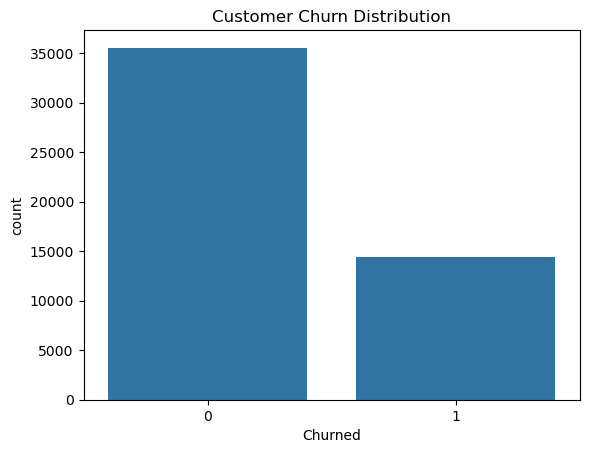

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churned', data=df)
plt.title("Customer Churn Distribution")
plt.show()

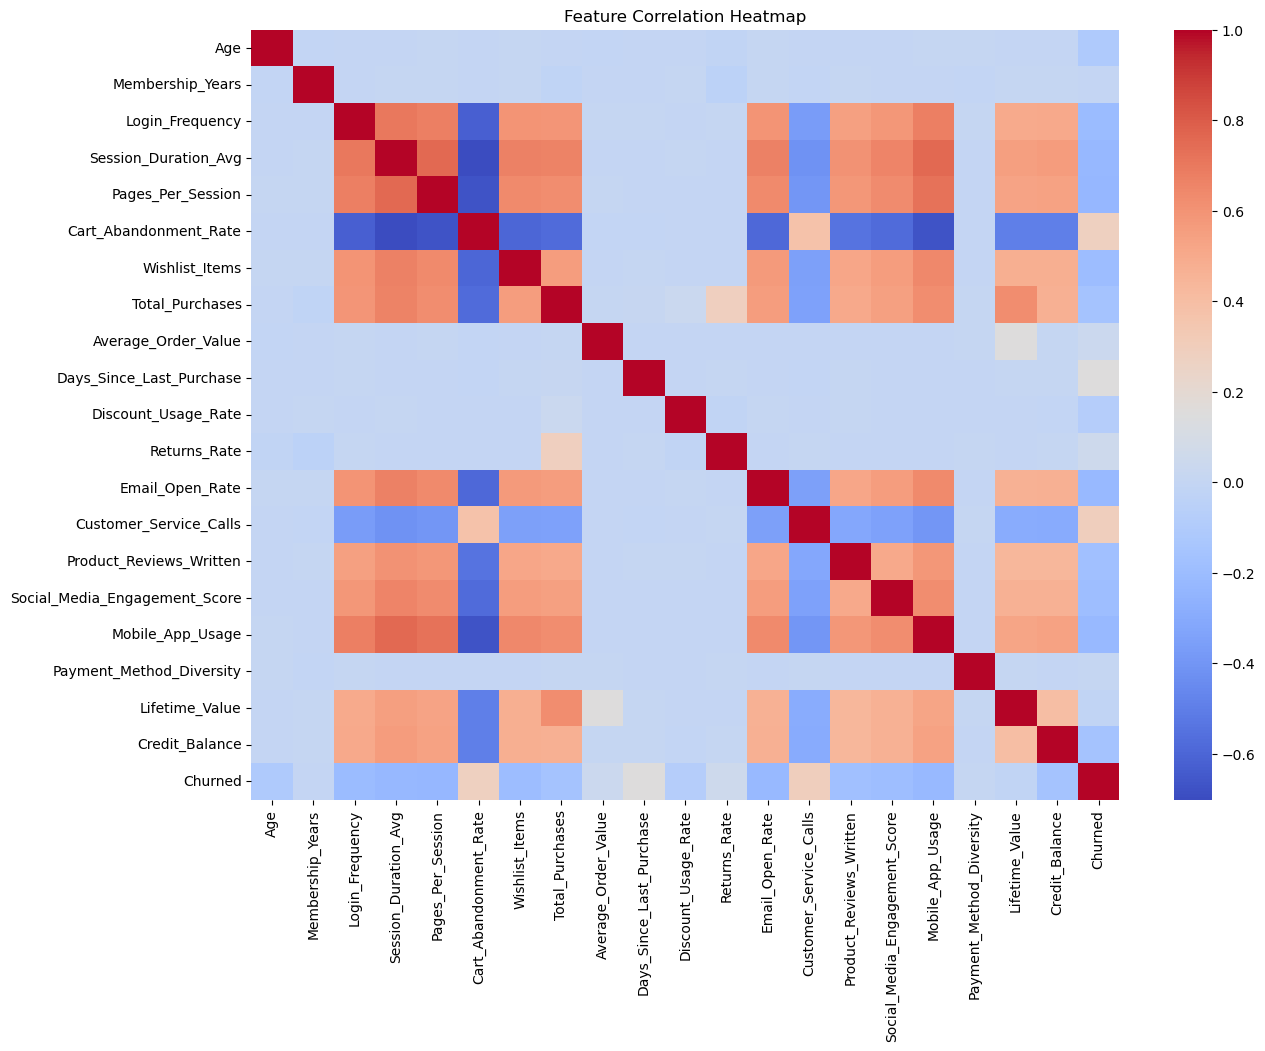

In [47]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

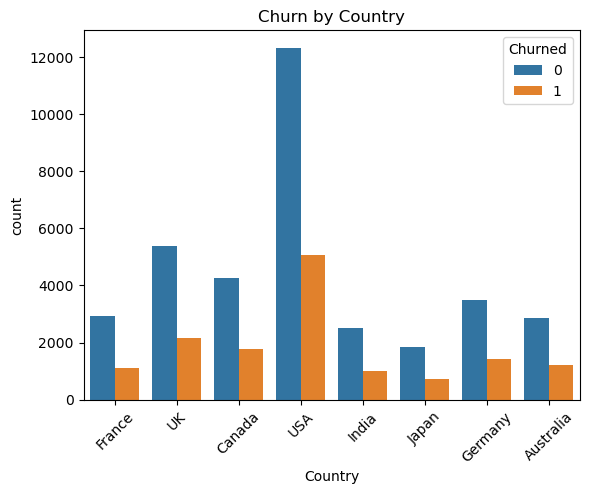

In [49]:
sns.countplot(x='Country', hue='Churned', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Country")
plt.show()